# GeoPAS Failure Analysis

This notebook rebuilds the failure-analysis workflow directly from raw inputs instead of reusing derived notebook state.

It:
- loads `relert.csv` plus protocol-specific `preds_*.csv.gz` files for `LIO`, `Random`, and `LPO`
- reconstructs realised per-row GeoPAS, SBS, and VBS outcomes
- regenerates the requested figures and CSV summaries
- validates the summary CSV tables and the SBS-non-improving subset

The `res_*.csv` files are used only as validation targets. All realised quantities are rebuilt from `relert.csv` and the prediction files.

In [ ]:
from dataclasses import dataclass
from io import StringIO
from pathlib import Path
import os
import re

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

FIGURE_FACE = "#f9f8f5"
AXES_FACE = "#ffffff"
GRID_COLOR = "#ddd4c6"
TEXT_COLOR = "#332c26"
GEOPAS_COLOR = "#4b84a0"
GEOPAS_EDGE = "#1f5873"
SBS_COLOR = "#d79b59"
SBS_EDGE = "#e19c2d"
VBS_COLOR = "#9ac9e2"
VBS_EDGE = "#839AB1"
EMPTY_NOTE_COLOR = "#8e8172"

DIM_HIST_COLORS = {
    2: "#8fb9aa",
    3: "#d4aa5f",
    5: "#cc7a5b",
    10: "#8c6aa8",
}
FGROUP_HIST_COLORS = {
    "f1-f5": "#4b84a0",
    "f6-f9": "#7aa05b",
    "f10-f14": "#d4aa5f",
    "f15-f19": "#c7775b",
    "f20-f24": "#8c6aa8",
}
NON_IMPROVING_HIST_COLORS = {
    "Other cells": "#c9d3dd",
    "In EXPECTED_NON_IMPROVING_CELLS": "#c7775b",
}

plt.rcParams.update(
    {
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "figure.facecolor": FIGURE_FACE,
        "savefig.facecolor": FIGURE_FACE,
        "axes.facecolor": AXES_FACE,
        "axes.edgecolor": "#665c50",
        "axes.labelcolor": TEXT_COLOR,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "axes.titleweight": "semibold",
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "font.family": "DejaVu Serif",
        "text.color": TEXT_COLOR,
        "xtick.color": TEXT_COLOR,
        "ytick.color": TEXT_COLOR,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 13,
        "legend.frameon": True,
        "legend.fancybox": False,
        "legend.facecolor": AXES_FACE,
        "legend.edgecolor": GRID_COLOR,
        "lines.linewidth": 2.2,
    }
)

ALG_COLS = [
    "BrentSTEPqi_Posik",
    "BrentSTEPrr_Posik",
    "CMA-CSA_Atamna",
    "HCMA_loshchilov_noiseless",
    "HMLSL_pal_noiseless",
    "IPOP400D_auger_noiseless",
    "MCS_huyer_noiseless",
    "M_LSL_pal_noiseless",
    "OQNLP_pal_noiseless",
    "SMAC-BBOB_hutter_noiseless",
    "fmincon_pal_noiseless",
    "fminunc_pal_noiseless",
]

PROBLEM_GROUP_ORDER = ["f1-f5", "f6-f9", "f10-f14", "f15-f19", "f20-f24", "all"]
DIM_ORDER = [2, 3, 5, 10, "all"]

EXPECTED_NON_IMPROVING_CELLS = {
    ("f1-f5", 3),
    ("f1-f5", 5),
    ("f1-f5", 10),
    ("f15-f19", 3),
    ("f15-f19", 5),
    ("f20-f24", 3),
}

PARAM_PATTERN = re.compile(
    r"^(?P<scale>scale(?:log|raw))_tail(?P<tail>\d+)_cap(?P<cap>[0-9.]+)_thr(?P<thr>[0-9.]+)_"
    r"scale(?P<scale_value>[0-9.]+)_dual(?P<dual>\d+)_w(?P<w>[0-9.]+)_tau(?P<tau>[0-9.]+)_pen(?P<pen>[0-9.]+)$"
)


def find_workspace_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "train_parallel.py").exists() and (candidate / "functions").exists():
            return candidate
    raise FileNotFoundError("Could not locate the GeoPAS workspace root from the current working directory.")


WORKSPACE_ROOT = find_workspace_root(Path.cwd().resolve())
PROJECT_ROOT = Path(
    os.environ.get("PROJECT_ROOT", os.environ.get("GEOPAS_PROJECT_ROOT", str(WORKSPACE_ROOT.parent)))
).resolve()


@dataclass(frozen=True)
class AnalysisConfig:
    repo_root: Path = PROJECT_ROOT
    workspace_root: Path = WORKSPACE_ROOT
    results_bundle: str = "results"
    parameter_set: str = "scalelog_tail1_cap3.0_thr3.0_scale1.0_dual1_w10.0_tau0.5_pen10.51"
    protocols: tuple[str, ...] = ("LIO", "Random", "LPO")
    seed: int = 17
    res: int = 8
    k_views: int = 32
    float_tol: float = 1e-9
    csv_compare_tol: float = 5e-4
    strict_target_count_validation: bool = False

    @property
    def label_path(self) -> Path:
        return self.workspace_root / "data_generation" / "performances" / "relert.csv"

    @property
    def bbob_root(self) -> Path:
        return self.repo_root / "results" / "bbob_by_deepela" / self.results_bundle / "bbob"

    @property
    def output_dir(self) -> Path:
        return (
            self.workspace_root
            / "analysis_outputs"
            / "failure_analysis"
            / f"{self.parameter_set}__seed{self.seed}__res{self.res}__k{self.k_views}"
        )


config = AnalysisConfig()
config.output_dir.mkdir(parents=True, exist_ok=True)
hist_count_scale = "raw"           # Options: "log", "raw"
hist_color_by = 'none'    # Options: "non_improving" "dim", "'fgroup'", "none"
hist_group_target = "geopas"       # Options: "geopas", "sbs", "both"

print(f"Workspace root: {config.workspace_root}")
print(f"Project root: {config.repo_root}")
print(f"Parameter set: {config.parameter_set}")
print(f"Protocols: {config.protocols}")
print(f"Histogram count scale: {hist_count_scale}")
print(f"Histogram colour grouping: {hist_color_by}")
print(f"Histogram grouped target: {hist_group_target}")
print(f"Label path: {config.label_path}")
print(f"Output directory: {config.output_dir}")

Parameter set: scalelog_tail1_cap3.0_thr3.0_scale1.0_dual1_w10.0_tau0.5_pen10.51
Protocols: ('LIO', 'Random', 'LPO')
Histogram count scale: raw
Histogram colour grouping: none
Histogram grouped target: geopas
Output directory: /data1/home/jw1017/AS_BBO_REBUILT/GeoPAS_v1/analysis_outputs/failure_analysis/scalelog_tail1_cap3.0_thr3.0_scale1.0_dual1_w10.0_tau0.5_pen10.51__seed17__res8__k32


## Utility Functions

The next cells define reusable helpers for loading files, reconstructing realised outcomes, aggregating summaries, plotting, and validating against the `res_*.csv` files.

In [110]:
def parse_parameter_set(parameter_set: str) -> dict[str, str]:
    match = PARAM_PATTERN.fullmatch(parameter_set)
    if match is None:
        raise ValueError(f"Could not parse parameter_set={parameter_set!r}")
    return match.groupdict()


def build_protocol_paths(config: AnalysisConfig, protocol: str) -> dict[str, Path]:
    tokens = parse_parameter_set(config.parameter_set)
    protocol_upper = protocol.upper()
    protocol_lower = protocol.lower()
    base = config.bbob_root / config.parameter_set / protocol_lower / f"seed{config.seed}" / protocol_upper
    stem = (
        f"tailpenalty_{tokens['tail']}_taillamcap_{tokens['cap']}_taillamthr_{tokens['thr']}_"
        f"catlossweight_{tokens['w']}_cattau_{tokens['tau']}_catpenalty_{tokens['pen']}_"
        f"res_{config.res}_k_views_{config.k_views}"
    )
    return {
        "base": base,
        "pred": base / f"preds_{stem}.csv.gz",
        "result": base / f"res_{stem}.csv",
    }


def fgroup_from_problem(problem: str) -> str:
    fid = int(str(problem).lower().lstrip("f"))
    if 1 <= fid <= 5:
        return "f1-f5"
    if 6 <= fid <= 9:
        return "f6-f9"
    if 10 <= fid <= 14:
        return "f10-f14"
    if 15 <= fid <= 19:
        return "f15-f19"
    if 20 <= fid <= 24:
        return "f20-f24"
    raise ValueError(f"Unsupported problem label: {problem!r}")


def ensure_algorithm_columns(df: pd.DataFrame, meta_cols: list[str], file_label: str) -> None:
    actual = [col for col in df.columns if col not in meta_cols]
    if actual != ALG_COLS:
        raise ValueError(
            f"{file_label} algorithm columns do not match the expected ordering.\n"
            f"Expected: {ALG_COLS}\nActual:   {actual}"
        )


def load_relert_table(config: AnalysisConfig) -> pd.DataFrame:
    label_df = pd.read_csv(config.label_path)
    label_df["Problem"] = label_df["Problem"].astype(str).str.lower()
    label_df["Dim"] = label_df["Dim"].astype(int)
    ensure_algorithm_columns(label_df, ["Problem", "Dim"], str(config.label_path))
    if len(label_df) != 96:
        raise ValueError(f"Expected 96 label rows, found {len(label_df)}")
    return label_df


def load_prediction_table(pred_path: Path) -> pd.DataFrame:
    pred_df = pd.read_csv(pred_path)
    pred_df["Problem"] = pred_df["Problem"].astype(str).str.lower()
    pred_df["Dim"] = pred_df["Dim"].astype(int)
    pred_df["Instance"] = pred_df["Instance"].astype(int)
    pred_df["Repetition"] = pred_df["Repetition"].astype(int)
    ensure_algorithm_columns(pred_df, ["Problem", "Dim", "Instance", "Repetition"], str(pred_path))
    if len(pred_df) != 4800:
        raise ValueError(f"Expected 4800 prediction rows in {pred_path.name}, found {len(pred_df)}")
    return pred_df


def compute_sbs_algorithm(label_df: pd.DataFrame) -> str:
    return label_df[ALG_COLS].mean(axis=0).idxmin()


def build_label_baseline_frame(label_df: pd.DataFrame, sbs_alg: str) -> pd.DataFrame:
    baseline_df = label_df[["Problem", "Dim"]].copy()
    baseline_df["FGroup"] = baseline_df["Problem"].map(fgroup_from_problem)
    baseline_df["sbs_alg"] = sbs_alg
    baseline_df["sbs_score"] = label_df[sbs_alg].to_numpy(dtype=float)
    baseline_df["vbs_alg"] = label_df[ALG_COLS].idxmin(axis=1)
    baseline_df["vbs_score"] = label_df[ALG_COLS].min(axis=1).to_numpy(dtype=float)
    return baseline_df


def validate_prediction_alignment(pred_df: pd.DataFrame, label_df: pd.DataFrame) -> pd.DataFrame:
    aligned = pred_df[["Problem", "Dim", "Instance", "Repetition"]].merge(
        label_df[["Problem", "Dim"] + ALG_COLS],
        on=["Problem", "Dim"],
        how="left",
        validate="many_to_one",
    )
    if aligned[ALG_COLS].isna().any().any():
        missing = aligned.loc[aligned[ALG_COLS].isna().any(axis=1), ["Problem", "Dim"]].drop_duplicates()
        raise ValueError(
            "Prediction rows could not be aligned to relert.csv on (Problem, Dim).\n"
            f"Missing keys:\n{missing.to_string(index=False)}"
        )
    return aligned


def build_protocol_analysis_df(protocol: str, label_df: pd.DataFrame, config: AnalysisConfig) -> tuple[pd.DataFrame, dict[str, Path]]:
    paths = build_protocol_paths(config, protocol)
    pred_df = load_prediction_table(paths["pred"])
    aligned = validate_prediction_alignment(pred_df, label_df)

    pred_mat = pred_df[ALG_COLS].to_numpy(dtype=float)
    true_mat = aligned[ALG_COLS].to_numpy(dtype=float)
    alg_array = np.array(ALG_COLS, dtype=object)

    as_idx = pred_mat.argmin(axis=1)
    scratch = pred_mat.copy()
    scratch[np.arange(len(scratch)), as_idx] = np.inf
    second_idx = scratch.argmin(axis=1)

    sbs_alg = compute_sbs_algorithm(label_df)
    sbs_idx = ALG_COLS.index(sbs_alg)
    vbs_idx = true_mat.argmin(axis=1)

    protocol_df = pred_df[["Problem", "Dim", "Instance", "Repetition"]].copy()
    protocol_df["Protocol"] = protocol
    protocol_df["FGroup"] = protocol_df["Problem"].map(fgroup_from_problem)
    protocol_df["as_alg"] = alg_array[as_idx]
    protocol_df["predicted_as_score"] = pred_mat[np.arange(len(pred_mat)), as_idx]
    protocol_df["predicted_margin"] = pred_mat[np.arange(len(pred_mat)), second_idx] - pred_mat[np.arange(len(pred_mat)), as_idx]
    protocol_df["as_score"] = true_mat[np.arange(len(true_mat)), as_idx]
    protocol_df["sbs_alg"] = sbs_alg
    protocol_df["sbs_score"] = true_mat[:, sbs_idx]
    protocol_df["vbs_alg"] = alg_array[vbs_idx]
    protocol_df["vbs_score"] = true_mat[np.arange(len(true_mat)), vbs_idx]
    return protocol_df, paths


def reduce_values(values: np.ndarray, metric: str) -> float:
    values = np.asarray(values, dtype=float)
    if metric == "Mean":
        return float(np.mean(values))
    if metric == "Median":
        return float(np.median(values))
    if metric == "P90":
        return float(np.quantile(values, 0.9))
    raise ValueError(f"Unsupported metric: {metric}")


def build_metric_table(frame: pd.DataFrame, value_col: str, metric: str) -> pd.DataFrame:
    rows = []
    for group in PROBLEM_GROUP_ORDER:
        row = {"Problem Group": group}
        group_mask = np.ones(len(frame), dtype=bool) if group == "all" else frame["FGroup"].to_numpy() == group
        for dim in DIM_ORDER:
            dim_mask = np.ones(len(frame), dtype=bool) if dim == "all" else frame["Dim"].to_numpy() == int(dim)
            subset = frame.loc[group_mask & dim_mask, value_col].to_numpy(dtype=float)
            row[dim] = reduce_values(subset, metric)
        rows.append(row)
    return pd.DataFrame(rows)


def build_protocol_cell_summary(protocol_df: pd.DataFrame) -> pd.DataFrame:
    grouped = protocol_df.groupby(["FGroup", "Dim"], as_index=False)
    return grouped.agg(
        row_count=("as_score", "size"),
        as_mean=("as_score", "mean"),
        as_median=("as_score", "median"),
        as_p90=("as_score", lambda values: np.quantile(values, 0.9)),
        sbs_mean=("sbs_score", "mean"),
        sbs_median=("sbs_score", "median"),
        sbs_p90=("sbs_score", lambda values: np.quantile(values, 0.9)),
        vbs_mean=("vbs_score", "mean"),
        vbs_median=("vbs_score", "median"),
        vbs_p90=("vbs_score", lambda values: np.quantile(values, 0.9)),
    )


def build_protocol_level_summary(protocol: str, protocol_df: pd.DataFrame, label_baseline_df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "Protocol": protocol,
                "as_mean": protocol_df["as_score"].mean(),
                "as_median": protocol_df["as_score"].median(),
                "as_p90": np.quantile(protocol_df["as_score"], 0.9),
                "sbs_mean_broadcast": protocol_df["sbs_score"].mean(),
                "sbs_median_broadcast": protocol_df["sbs_score"].median(),
                "sbs_p90_broadcast": np.quantile(protocol_df["sbs_score"], 0.9),
                "sbs_mean_summary_style": label_baseline_df["sbs_score"].mean(),
                "sbs_median_summary_style": label_baseline_df["sbs_score"].median(),
                "sbs_p90_summary_style": np.quantile(label_baseline_df["sbs_score"], 0.9),
                "vbs_mean_summary_style": label_baseline_df["vbs_score"].mean(),
                "vbs_median_summary_style": label_baseline_df["vbs_score"].median(),
                "vbs_p90_summary_style": np.quantile(label_baseline_df["vbs_score"], 0.9),
            }
        ]
    )


def compute_non_improving_cells(cell_summary_df: pd.DataFrame, tol: float) -> set[tuple[str, int]]:
    pivot = cell_summary_df.pivot_table(index=["FGroup", "Dim"], columns="Protocol", values=["as_p90", "sbs_p90"])
    keep_mask = np.ones(len(pivot), dtype=bool)
    for protocol in config.protocols:
        keep_mask &= pivot[("as_p90", protocol)].to_numpy() >= pivot[("sbs_p90", protocol)].to_numpy() - tol
    return {(fgroup, int(dim)) for fgroup, dim in pivot.index[keep_mask]}


def add_tail_flags(protocol_df: pd.DataFrame, tail_threshold: float) -> pd.DataFrame:
    out = protocol_df.copy()
    out["as_tail_T"] = out["as_score"] > tail_threshold
    out["sbs_tail_T"] = out["sbs_score"] > tail_threshold
    out["as_tail_1000"] = out["as_score"] > 1000.0
    out["sbs_tail_1000"] = out["sbs_score"] > 1000.0
    return out

In [111]:
RESULT_BLOCK_LABELS = {"Mean", "Median", "P90"}
RESULT_SECTION_LABELS = {"AS", "VBS", "SBS", "Gap_Closure"}
ALL_RESULT_LABELS = RESULT_BLOCK_LABELS | {
    "Log_Mean",
    "Log_Median",
    "Log_P90",
    "Accuracies",
    "Catastrophe_Accuracies",
    "F1",
    "Pick_Rate",
    "VBS_Pick_Rate",
}


def parse_result_csv_tables(result_path: Path) -> dict[str, dict[str, pd.DataFrame]]:
    lines = result_path.read_text().splitlines()
    parsed: dict[str, dict[str, pd.DataFrame]] = {}
    i = 0
    while i < len(lines):
        label = lines[i].strip()
        if label not in RESULT_BLOCK_LABELS:
            i += 1
            continue
        parsed[label] = {}
        i += 1
        while i < len(lines):
            current = lines[i].strip()
            if current == "":
                i += 1
                continue
            if current in ALL_RESULT_LABELS and current not in RESULT_SECTION_LABELS:
                break
            if current not in RESULT_SECTION_LABELS:
                i += 1
                continue
            section = current
            block_lines = []
            i += 1
            while i < len(lines):
                current = lines[i].strip()
                if current == "":
                    i += 1
                    break
                if current in ALL_RESULT_LABELS or current in RESULT_SECTION_LABELS:
                    break
                block_lines.append(lines[i])
                i += 1
            parsed[label][section] = pd.read_csv(StringIO("\n".join(block_lines)))
    return parsed


def normalize_summary_table(table: pd.DataFrame) -> pd.DataFrame:
    out = table.copy()
    first_col = out.columns[0]
    if first_col != "Problem Group":
        out = out.rename(columns={first_col: "Problem Group"})
    out["Problem Group"] = out["Problem Group"].astype(str)
    out = out.rename(columns={col: str(col) for col in out.columns[1:]})
    return out


def round_summary_table(table: pd.DataFrame) -> pd.DataFrame:
    out = normalize_summary_table(table)
    numeric_cols = out.columns[1:]
    out.loc[:, numeric_cols] = out.loc[:, numeric_cols].astype(float).round(3)
    return out


def flatten_summary_table(table: pd.DataFrame, protocol: str, metric: str, section: str) -> pd.DataFrame:
    normalized = round_summary_table(table)
    rows = []
    for _, row in normalized.iterrows():
        for dim in ["2", "3", "5", "10", "all"]:
            rows.append(
                {
                    "Protocol": protocol,
                    "Metric": metric,
                    "Section": section,
                    "Problem Group": row["Problem Group"],
                    "Dim": dim,
                    "value": float(row[dim]),
                }
            )
    return pd.DataFrame(rows)


def compare_summary_tables(
    observed_table: pd.DataFrame,
    expected_table: pd.DataFrame,
    protocol: str,
    metric: str,
    section: str,
    tol: float,
) -> pd.DataFrame:
    observed_long = flatten_summary_table(observed_table, protocol, metric, section).rename(columns={"value": "observed"})
    expected_long = flatten_summary_table(expected_table, protocol, metric, section).rename(columns={"value": "expected"})
    merged = observed_long.merge(
        expected_long,
        on=["Protocol", "Metric", "Section", "Problem Group", "Dim"],
        how="inner",
    )
    merged["abs_diff"] = (merged["observed"] - merged["expected"]).abs()
    merged["within_tol"] = merged["abs_diff"] <= tol
    return merged


def build_tail_quadrant_table(analysis_by_protocol: dict[str, pd.DataFrame], tail_threshold: float) -> pd.DataFrame:
    rows = []
    for protocol, protocol_df in analysis_by_protocol.items():
        for threshold_label, as_flag, sbs_flag, threshold_value in [
            ("T", protocol_df["as_tail_T"], protocol_df["sbs_tail_T"], tail_threshold),
            ("1000", protocol_df["as_tail_1000"], protocol_df["sbs_tail_1000"], 1000.0),
        ]:
            total = len(protocol_df)
            neither = int((~as_flag & ~sbs_flag).sum())
            sbs_only = int((~as_flag & sbs_flag).sum())
            both = int((as_flag & sbs_flag).sum())
            as_only = int((as_flag & ~sbs_flag).sum())
            rows.append(
                {
                    "Protocol": protocol,
                    "threshold_label": threshold_label,
                    "threshold_value": threshold_value,
                    "Neither": neither,
                    "SBS only": sbs_only,
                    "Both": both,
                    "AS only": as_only,
                    "fraction_non_tail": neither / total,
                    "geopas_only_tail_rate": as_only / total,
                    "geopas_only_outliers_zero": bool(threshold_label != "1000" or as_only == 0),
                }
            )
    return pd.DataFrame(rows)


def style_axes(ax: plt.Axes, *, x_grid: bool = False, y_grid: bool = True) -> None:
    ax.set_facecolor(AXES_FACE)
    ax.set_axisbelow(True)
    ax.spines["left"].set_color("#665c50")
    ax.spines["bottom"].set_color("#665c50")
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.tick_params(axis="both", colors=TEXT_COLOR)
    if y_grid:
        ax.grid(axis="y", which="major", color=GRID_COLOR, linewidth=0.85, alpha=0.78)
    if x_grid:
        ax.grid(axis="x", which="major", color=GRID_COLOR, linewidth=0.75, alpha=0.58)


def finalize_legend(ax: plt.Axes, *, loc: str = "best", title: str | None = None) -> None:
    handles, labels = ax.get_legend_handles_labels()
    if not handles:
        return
    ax.legend(loc=loc, frameon=True, facecolor=AXES_FACE, edgecolor=GRID_COLOR, title=title, title_fontsize=10)


def make_log_bins(*value_arrays: np.ndarray, num_bins: int = 50) -> np.ndarray:
    positive = np.concatenate([np.asarray(values, dtype=float) for values in value_arrays])
    positive = positive[np.isfinite(positive) & (positive > 0)]
    lower = max(1.0, float(np.min(positive)))
    upper = float(np.max(positive))
    return np.logspace(np.log10(lower), np.log10(upper), num_bins)


def resolve_histogram_grouping(
    protocol_df: pd.DataFrame,
    color_by: str,
) -> tuple[np.ndarray | None, list[str] | None, list[str] | None, str | None]:
    normalized = color_by.strip().lower()
    if normalized in {"none", "off"}:
        return None, None, None, None

    if normalized in {"dim", "dimension"}:
        labels = np.array([f"d={int(dim)}" for dim in protocol_df["Dim"]], dtype=object)
        observed = set(labels)
        order = [f"d={int(dim)}" for dim in DIM_ORDER if dim != "all" and f"d={int(dim)}" in observed]
        colors = [DIM_HIST_COLORS[int(label.split("=")[1])] for label in order]
        return labels, order, colors, "Rows grouped by dimension"

    if normalized in {"fgroup", "function family", "family"}:
        labels = protocol_df["FGroup"].astype(str).to_numpy(dtype=object)
        observed = set(labels)
        order = [group for group in PROBLEM_GROUP_ORDER if group != "all" and group in observed]
        colors = [FGROUP_HIST_COLORS[group] for group in order]
        return labels, order, colors, "Rows grouped by function family"

    if normalized in {"non_improving", "non-improving", "expected_non_improving_cells"}:
        labels = np.array(
            [
                "In EXPECTED_NON_IMPROVING_CELLS"
                if (str(fgroup), int(dim)) in EXPECTED_NON_IMPROVING_CELLS
                else "Other cells"
                for fgroup, dim in zip(protocol_df["FGroup"], protocol_df["Dim"])
            ],
            dtype=object,
        )
        order = ["Other cells", "In EXPECTED_NON_IMPROVING_CELLS"]
        colors = [NON_IMPROVING_HIST_COLORS[label] for label in order]
        return labels, order, colors, "Rows grouped by cell type"

    raise ValueError(
        "color_by must be one of {'none', 'dim', 'fgroup', 'non_improving'}; "
        f"got {color_by!r}"
    )


def draw_grouped_histogram(
    ax: plt.Axes,
    scores: np.ndarray,
    bins: np.ndarray,
    row_groups: np.ndarray,
    group_order: list[str],
    group_colors: list[str],
    *,
    alpha: float,
    hatch: str | None,
    edgecolor: str,
    linewidth: float,
    zorder: int,
    labels: list[str] | None,
    histtype: str = "barstacked",
) -> None:
    grouped_scores = []
    grouped_labels = []
    grouped_colors = []
    for label, color in zip(group_order, group_colors):
        mask = row_groups == label
        if mask.any():
            grouped_scores.append(scores[mask])
            grouped_colors.append(color)
            if labels is not None:
                grouped_labels.append(label)

    if not grouped_scores:
        return

    ax.hist(
        grouped_scores,
        bins=bins,
        stacked=True,
        histtype=histtype,
        alpha=alpha,
        color=grouped_colors,
        edgecolor=edgecolor,
        linewidth=linewidth,
        hatch=hatch,
        label=(grouped_labels if labels is not None else None),
        zorder=zorder,
    )


def plot_histogram_comparison(
    ax: plt.Axes,
    as_scores: np.ndarray,
    sbs_scores: np.ndarray,
    bins: np.ndarray,
    title: str,
    show_legend: bool,
    count_scale: str = "log",
    row_groups: np.ndarray | None = None,
    group_order: list[str] | None = None,
    group_colors: list[str] | None = None,
    group_target: str = "geopas",
    legend_title: str | None = None,
) -> None:
    normalized_count_scale = count_scale.lower()
    if normalized_count_scale not in {"log", "linear", "raw"}:
        raise ValueError(
            "count_scale must be one of {'log', 'linear', 'raw'}; "
            f"got {count_scale!r}"
        )
    normalized_group_target = group_target.strip().lower()
    if normalized_group_target not in {"none", "geopas", "sbs", "both"}:
        raise ValueError(
            "group_target must be one of {'none', 'geopas', 'sbs', 'both'}; "
            f"got {group_target!r}"
        )

    as_scores = np.asarray(as_scores, dtype=float)
    sbs_scores = np.asarray(sbs_scores, dtype=float)

    if normalized_group_target == "none" or row_groups is None:
        ax.hist(as_scores, bins=bins, histtype="stepfilled", alpha=0.18, color=GEOPAS_COLOR, edgecolor="none", zorder=1)
        ax.hist(as_scores, bins=bins, histtype="step", linewidth=2.2, color=GEOPAS_EDGE, label="GeoPAS", zorder=3)
        ax.hist(
            sbs_scores,
            bins=bins,
            histtype="step",
            linewidth=2.2,
            color=SBS_EDGE,
            linestyle=(0, (6.0, 2.4)),
            label="SBS",
            zorder=4,
        )
    else:
        if group_order is None or group_colors is None:
            raise ValueError("group_order and group_colors are required when row_groups is provided")
        row_groups = np.asarray(row_groups, dtype=object)

        if normalized_group_target in {"geopas", "both"}:
            draw_grouped_histogram(
                ax,
                as_scores,
                bins,
                row_groups,
                group_order,
                group_colors,
                alpha=0.62,
                hatch=None,
                edgecolor=AXES_FACE,
                linewidth=0.45,
                zorder=1,
                labels=group_order,
            )
            ax.hist(as_scores, bins=bins, histtype="step", linewidth=2.2, color=GEOPAS_EDGE, label="GeoPAS total", zorder=4)
        else:
            ax.hist(as_scores, bins=bins, histtype="stepfilled", alpha=0.18, color=GEOPAS_COLOR, edgecolor="none", zorder=1)
            ax.hist(as_scores, bins=bins, histtype="step", linewidth=2.2, color=GEOPAS_EDGE, label="GeoPAS", zorder=4)

        if normalized_group_target in {"sbs", "both"}:
            draw_grouped_histogram(
                ax,
                sbs_scores,
                bins,
                row_groups,
                group_order,
                group_colors,
                alpha=0.18,
                hatch="////",
                edgecolor=SBS_EDGE,
                linewidth=0.4,
                zorder=2,
                labels=None,
            )
            ax.hist(
                sbs_scores,
                bins=bins,
                histtype="step",
                linewidth=2.2,
                color=SBS_EDGE,
                linestyle=(0, (6.0, 2.4)),
                label="SBS total",
                zorder=5,
            )
        else:
            ax.hist(
                sbs_scores,
                bins=bins,
                histtype="step",
                linewidth=2.2,
                color=SBS_EDGE,
                linestyle=(0, (6.0, 2.4)),
                label="SBS",
                zorder=5,
            )

        if normalized_group_target == "both" and legend_title is not None:
            legend_title = f"{legend_title} (solid=GeoPAS, hatched=SBS)"
        elif normalized_group_target == "sbs" and legend_title is not None:
            legend_title = legend_title.replace("Rows grouped", "SBS grouped", 1)

    ax.set_xscale("log")
    ax.set_yscale("log" if normalized_count_scale == "log" else "linear")
    ax.set_xlabel("relERT")
    ax.set_ylabel("Count")
    ax.set_title(title, loc="left", pad=8)
    ax.xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
    style_axes(ax, y_grid=True)
    if show_legend:
        finalize_legend(ax, loc="upper right", title=legend_title)


def build_pick_count_frame(df_subset: pd.DataFrame) -> pd.DataFrame:
    as_counts = df_subset["as_alg"].value_counts().reindex(ALG_COLS, fill_value=0)
    vbs_counts = df_subset["vbs_alg"].value_counts().reindex(ALG_COLS, fill_value=0)
    counts = pd.DataFrame(
        {
            "Algorithm": ALG_COLS,
            "GeoPAS count": as_counts.to_numpy(),
            "VBS count": vbs_counts.to_numpy(),
        }
    )
    counts = counts.loc[(counts["GeoPAS count"] > 0) | (counts["VBS count"] > 0)].copy()
    counts = counts.sort_values(["VBS count", "GeoPAS count", "Algorithm"], ascending=[False, False, True]).reset_index(drop=True)
    return counts


def plot_pick_frequency_panel(ax: plt.Axes, df_subset: pd.DataFrame, title: str, show_legend: bool) -> None:
    if df_subset.empty:
        ax.text(0.5, 0.5, "No rows", ha="center", va="center", color=EMPTY_NOTE_COLOR, transform=ax.transAxes)
        ax.set_title(title, loc="left")
        ax.set_axis_off()
        return

    counts = build_pick_count_frame(df_subset)
    y = np.arange(len(counts))
    ax.barh(
        y - 0.18,
        counts["VBS count"],
        height=0.32,
        color=VBS_COLOR,
        edgecolor=VBS_EDGE,
        linewidth=0.65,
        hatch="////",
        label="VBS",
    )
    ax.barh(
        y + 0.18,
        counts["GeoPAS count"],
        height=0.32,
        color=GEOPAS_COLOR,
        edgecolor=GEOPAS_EDGE,
        linewidth=0.65,
        label="GeoPAS",
    )
    ax.set_yticks(y)
    ax.set_yticklabels(counts["Algorithm"], fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlabel("Count")
    ax.set_title(title, loc="left", pad=8)
    max_count = float(counts[["VBS count", "GeoPAS count"]].to_numpy().max()) if len(counts) else 1.0
    ax.set_xlim(0.0, max(1.0, max_count * 1.12))
    style_axes(ax, x_grid=True, y_grid=False)
    if show_legend:
        finalize_legend(ax, loc="lower right")


def subset_non_improving_rows(protocol_df: pd.DataFrame, non_improving_cells: set[tuple[str, int]]) -> pd.DataFrame:
    mask = [(fgroup, int(dim)) in non_improving_cells for fgroup, dim in zip(protocol_df["FGroup"], protocol_df["Dim"])]
    return protocol_df.loc[mask].copy()


def build_survival_grid(analysis_by_protocol: dict[str, pd.DataFrame], num_points: int = 200) -> np.ndarray:
    max_value = 1.0
    for protocol_df in analysis_by_protocol.values():
        max_value = max(max_value, float(protocol_df[["as_score", "sbs_score"]].to_numpy(dtype=float).max()))
    return np.logspace(0.0, np.log10(max_value), num_points)


def survival_probability(values: np.ndarray, grid: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    return (values[:, None] > grid[None, :]).mean(axis=0)


def plot_survival_panel(ax: plt.Axes, df_subset: pd.DataFrame, grid: np.ndarray, title: str, show_legend: bool) -> None:
    if df_subset.empty:
        ax.text(0.5, 0.5, "No rows", ha="center", va="center", color=EMPTY_NOTE_COLOR, transform=ax.transAxes)
        ax.set_title(title, loc="left")
        ax.set_axis_off()
        return

    geopas_survival = survival_probability(df_subset["as_score"].to_numpy(dtype=float), grid)
    sbs_survival = survival_probability(df_subset["sbs_score"].to_numpy(dtype=float), grid)
    ax.step(grid, geopas_survival, where="post", color=GEOPAS_EDGE, linewidth=2.3, label="GeoPAS", zorder=3)
    ax.step(
        grid,
        sbs_survival,
        where="post",
        color=SBS_EDGE,
        linewidth=2.15,
        linestyle=(0, (6.0, 2.4)),
        label="SBS",
        zorder=4,
    )
    ax.set_xscale("log")
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("t")
    ax.set_ylabel("P(relERT > t)")
    ax.set_title(title, loc="left", pad=8)
    ax.xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
    style_axes(ax, x_grid=True, y_grid=True)
    if show_legend:
        finalize_legend(ax, loc="upper right")


def save_dataframe(df: pd.DataFrame, path: Path, index: bool = False) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=index)
    return path

In [112]:
def canonical_problem_list_from_frame(frame: pd.DataFrame) -> list[str]:
    problems = sorted(pd.unique(frame["Problem"].astype(str).str.lower()))
    ordered: list[str] = []
    seen: set[str] = set()
    for problem in problems:
        match = re.match(r"^[fF]?(\d+)$", problem)
        if match is None:
            continue
        canonical = f"f{int(match.group(1))}"
        if canonical not in seen:
            seen.add(canonical)
            ordered.append(canonical)
    return ordered


def build_metric_table_allow_missing(frame: pd.DataFrame, value_col: str, metric: str) -> pd.DataFrame:
    fgroup_values = frame["FGroup"].to_numpy(dtype=object)
    dim_values = frame["Dim"].to_numpy(dtype=int)
    value_array = frame[value_col].to_numpy(dtype=float)

    rows = []
    for group in PROBLEM_GROUP_ORDER:
        row = {"Problem Group": group}
        group_mask = np.ones(len(frame), dtype=bool) if group == "all" else (fgroup_values == group)
        for dim in DIM_ORDER:
            dim_mask = np.ones(len(frame), dtype=bool) if dim == "all" else (dim_values == int(dim))
            subset = value_array[group_mask & dim_mask]
            row[dim] = np.nan if subset.size == 0 else reduce_values(subset, metric)
        rows.append(row)
    return pd.DataFrame(rows)


def build_protocol_fold_slices(
    protocol: str,
    protocol_df: pd.DataFrame,
    label_df: pd.DataFrame,
    config: AnalysisConfig,
) -> list[tuple[str, pd.DataFrame]]:
    protocol_upper = protocol.upper()
    instances_all = tuple(int(value) for value in getattr(config, "instances_all", (1, 2, 3, 4, 5)))
    n_splits = int(getattr(config, "n_splits", 5))

    if protocol_upper == "LIO":
        return [
            (f"inst_{instance}", protocol_df.loc[protocol_df["Instance"] == int(instance)].copy())
            for instance in instances_all
        ]

    if protocol_upper == "LPO":
        present_problems = set(protocol_df["Problem"].astype(str).str.lower())
        return [
            (f"prob_{problem}", protocol_df.loc[protocol_df["Problem"] == problem].copy())
            for problem in canonical_problem_list_from_frame(label_df)
            if problem in present_problems
        ]

    if protocol_upper == "RANDOM":
        group_keys: list[tuple[str, int, int]] = []
        for _, row in label_df.iterrows():
            problem = str(row["Problem"]).lower()
            dim = int(row["Dim"])
            for instance in instances_all:
                group_keys.append((problem, dim, int(instance)))

        n_groups = len(group_keys)
        if n_groups < n_splits:
            raise ValueError(
                "Random fold reconstruction requires n_groups >= n_splits; "
                f"got n_groups={n_groups}, n_splits={n_splits}."
            )

        rng_partition = np.random.default_rng(int(config.seed))
        perm = rng_partition.permutation(n_groups)
        fold_sizes = [n_groups // n_splits + (1 if i < (n_groups % n_splits) else 0) for i in range(n_splits)]

        fold_by_group: dict[tuple[str, int, int], int] = {}
        cursor = 0
        for fold_idx, fold_size in enumerate(fold_sizes):
            for group_idx in perm[cursor : cursor + fold_size]:
                fold_by_group[group_keys[int(group_idx)]] = fold_idx
            cursor += fold_size

        annotated = protocol_df.copy()
        annotated["fold_id"] = [
            f"split_{fold_by_group[(problem, int(dim), int(instance))]}"
            for problem, dim, instance in zip(
                annotated["Problem"].astype(str).str.lower(),
                annotated["Dim"].to_numpy(dtype=int),
                annotated["Instance"].to_numpy(dtype=int),
            )
        ]
        return [
            (
                f"split_{fold_idx}",
                annotated.loc[annotated["fold_id"] == f"split_{fold_idx}"].copy(),
            )
            for fold_idx in range(n_splits)
        ]

    raise ValueError(f"Unsupported protocol for fold reconstruction: {protocol!r}")


def build_fold_averaged_mean_as_table(
    protocol: str,
    protocol_df: pd.DataFrame,
    label_df: pd.DataFrame,
    config: AnalysisConfig,
) -> pd.DataFrame:
    ordered_dim_columns = ["2", "3", "5", "10", "all"]
    fold_matrices = []

    for _, fold_df in build_protocol_fold_slices(protocol, protocol_df, label_df, config):
        fold_table = build_metric_table_allow_missing(fold_df, "as_score", "Mean")
        fold_table = round_summary_table(fold_table)
        fold_table = fold_table.set_index("Problem Group").reindex(PROBLEM_GROUP_ORDER)
        fold_table = fold_table.loc[:, ordered_dim_columns].astype(float)
        fold_matrices.append(fold_table.to_numpy(dtype=float))

    averaged = np.nanmean(np.stack(fold_matrices, axis=0), axis=0)
    out = pd.DataFrame(averaged, columns=[2, 3, 5, 10, "all"])
    out.insert(0, "Problem Group", PROBLEM_GROUP_ORDER)
    return out


def build_observed_result_tables(
    protocol: str,
    protocol_df: pd.DataFrame,
    label_df: pd.DataFrame,
    label_baseline_df: pd.DataFrame,
    config: AnalysisConfig,
) -> dict[str, dict[str, pd.DataFrame]]:
    observed: dict[str, dict[str, pd.DataFrame]] = {}
    for metric in ["Mean", "Median", "P90"]:
        as_table = (
            build_fold_averaged_mean_as_table(protocol, protocol_df, label_df, config)
            if metric == "Mean"
            else build_metric_table(protocol_df, "as_score", metric)
        )
        observed[metric] = {
            "AS": as_table,
            "SBS": build_metric_table(label_baseline_df, "sbs_score", metric),
            "VBS": build_metric_table(label_baseline_df, "vbs_score", metric),
        }
    return observed

## Build Per-Protocol Analysis Data

This cell loads the label table once, reconstructs one unified per-row dataframe per protocol, computes the broadcast tail threshold, and saves the main intermediate CSVs.

In [113]:
label_df = load_relert_table(config)
sbs_alg = compute_sbs_algorithm(label_df)
label_baseline_df = build_label_baseline_frame(label_df, sbs_alg)

analysis_by_protocol: dict[str, pd.DataFrame] = {}
paths_by_protocol: dict[str, dict[str, Path]] = {}
result_tables_by_protocol: dict[str, dict[str, dict[str, pd.DataFrame]]] = {}
observed_tables_by_protocol: dict[str, dict[str, dict[str, pd.DataFrame]]] = {}
protocol_cell_summaries = []
protocol_level_summaries = []

for protocol in config.protocols:
    protocol_df, protocol_paths = build_protocol_analysis_df(protocol, label_df, config)
    analysis_by_protocol[protocol] = protocol_df
    paths_by_protocol[protocol] = protocol_paths
    result_tables_by_protocol[protocol] = parse_result_csv_tables(protocol_paths["result"])
    observed_tables_by_protocol[protocol] = build_observed_result_tables(
        protocol,
        protocol_df,
        label_df,
        label_baseline_df,
        config,
    )

    protocol_cell_summary = build_protocol_cell_summary(protocol_df)
    protocol_cell_summary["Protocol"] = protocol
    protocol_cell_summaries.append(protocol_cell_summary)
    protocol_level_summaries.append(build_protocol_level_summary(protocol, protocol_df, label_baseline_df))
    save_dataframe(protocol_df, config.output_dir / f"per_row_analysis__{protocol.lower()}.csv.gz")

cell_summary_df = pd.concat(protocol_cell_summaries, ignore_index=True)
protocol_level_summary_df = pd.concat(protocol_level_summaries, ignore_index=True)

# broadcast_tail_threshold = float(np.quantile(analysis_by_protocol[config.protocols[0]]["sbs_score"], 0.9)) # This is not interpolated, which is not standard, so replace with the hand-computed one
broadcast_tail_threshold = 12.477
summary_style_tail_threshold = float(np.quantile(label_baseline_df["sbs_score"], 0.9))

analysis_by_protocol = {
    protocol: add_tail_flags(protocol_df, broadcast_tail_threshold)
    for protocol, protocol_df in analysis_by_protocol.items()
}

non_improving_cells = compute_non_improving_cells(cell_summary_df, config.float_tol)
assert non_improving_cells == EXPECTED_NON_IMPROVING_CELLS, (
    f"Unexpected SBS-non-improving subset.\n"
    f"Observed: {sorted(non_improving_cells)}\nExpected: {sorted(EXPECTED_NON_IMPROVING_CELLS)}"
)

non_improving_df = pd.DataFrame(sorted(non_improving_cells), columns=["FGroup", "Dim"])
thresholds_df = pd.DataFrame(
    [
        {
            "threshold_name": "broadcast_T",
            "value": broadcast_tail_threshold,
            "definition": "90th percentile of the broadcast SBS per-row scores over the 4800-row dataframe",
        },
        {
            "threshold_name": "summary_style_T",
            "value": summary_style_tail_threshold,
            "definition": "90th percentile of the 96-row SBS ground-truth table used inside res_*.csv summary generation",
        },
        {
            "threshold_name": "extreme_threshold",
            "value": 1000.0,
            "definition": "Fixed extreme relERT threshold",
        },
    ]
)

save_dataframe(cell_summary_df, config.output_dir / "cell_summary_by_protocol.csv")
save_dataframe(protocol_level_summary_df, config.output_dir / "protocol_level_summary.csv")
save_dataframe(non_improving_df, config.output_dir / "sbs_non_improving_cells.csv")
save_dataframe(thresholds_df, config.output_dir / "thresholds.csv")

print(f"Global SBS algorithm: {sbs_alg}")
print(f"Broadcast tail threshold T: {broadcast_tail_threshold:.12g}")
print(f"Summary-style SBS P90 (for res_*.csv comparison): {summary_style_tail_threshold:.12g}")
print(f"Saved intermediate CSVs under: {config.output_dir}")

protocol_level_summary_df

Global SBS algorithm: HCMA_loshchilov_noiseless
Broadcast tail threshold T: 12.477
Summary-style SBS P90 (for res_*.csv comparison): 12.4765013957
Saved intermediate CSVs under: /data1/home/jw1017/AS_BBO_REBUILT/GeoPAS_v1/analysis_outputs/failure_analysis/scalelog_tail1_cap3.0_thr3.0_scale1.0_dual1_w10.0_tau0.5_pen10.51__seed17__res8__k32


,Protocol,as_mean,as_median,as_p90,sbs_mean_broadcast,sbs_median_broadcast,sbs_p90_broadcast,sbs_mean_summary_style,sbs_median_summary_style,sbs_p90_summary_style,vbs_mean_summary_style,vbs_median_summary_style,vbs_p90_summary_style
0,LIO,23.189441,1.137371,4.101215,30.373417,3.438422,14.862505,30.373417,3.438422,12.476501,1.0,1.0,1.0
1,Random,24.712321,1.273504,4.839779,30.373417,3.438422,14.862505,30.373417,3.438422,12.476501,1.0,1.0,1.0
2,LPO,21.395477,1.684286,7.039490,30.373417,3.438422,14.862505,30.373417,3.438422,12.476501,1.0,1.0,1.0


## Requested Outputs

The following cells regenerate the requested figures and the tail-quadrant table, then save them into the configured analysis output directory.

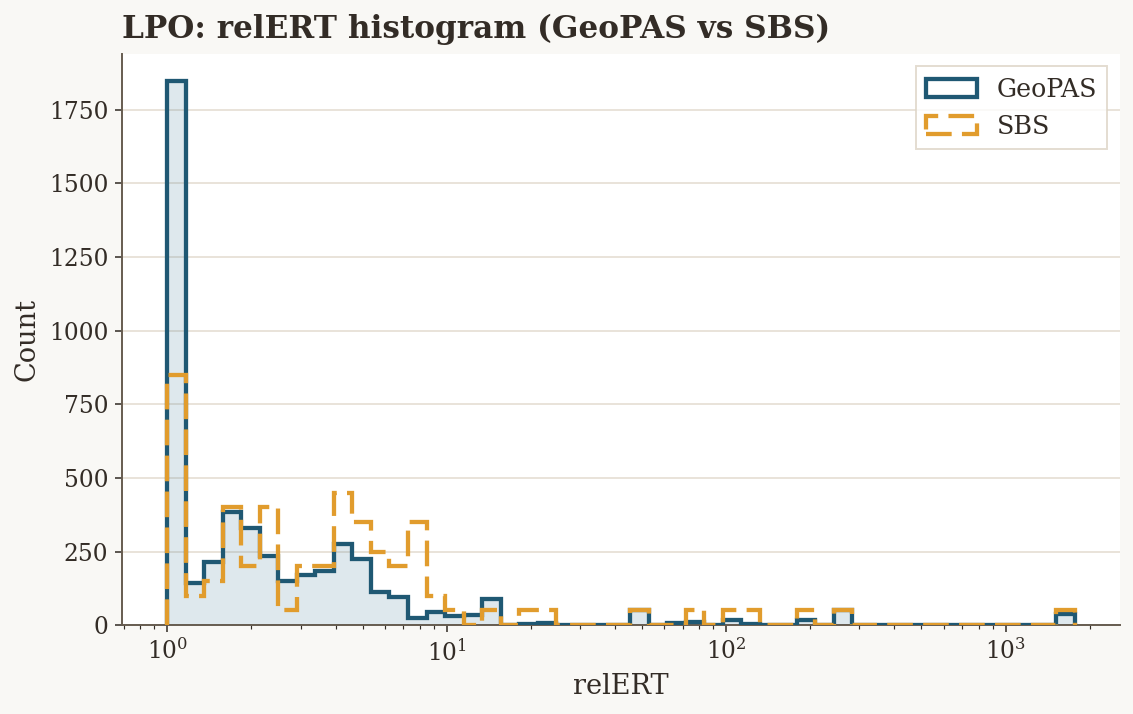

/data1/home/jw1017/AS_BBO_REBUILT/GeoPAS_v1/analysis_outputs/failure_analysis/scalelog_tail1_cap3.0_thr3.0_scale1.0_dual1_w10.0_tau0.5_pen10.51__seed17__res8__k32/fig_hist_relert_lpo_geopas_vs_sbs.svg


In [114]:
lpo_df = analysis_by_protocol["LPO"]
lpo_hist_bins = make_log_bins(lpo_df["as_score"].to_numpy(dtype=float), lpo_df["sbs_score"].to_numpy(dtype=float))
lpo_hist_groups, lpo_hist_group_order, lpo_hist_group_colors, lpo_hist_legend_title = resolve_histogram_grouping(
    lpo_df,
    hist_color_by,
)
fig_hist, ax_hist = plt.subplots(figsize=(8.2, 5.2), facecolor=FIGURE_FACE)
plot_histogram_comparison(
    ax_hist,
    lpo_df["as_score"].to_numpy(dtype=float),
    lpo_df["sbs_score"].to_numpy(dtype=float),
    bins=lpo_hist_bins,
    title="LPO: relERT histogram (GeoPAS vs SBS)",
    show_legend=True,
    count_scale=hist_count_scale,
    row_groups=lpo_hist_groups,
    group_order=lpo_hist_group_order,
    group_colors=lpo_hist_group_colors,
    group_target=hist_group_target,
    legend_title=lpo_hist_legend_title,
)
fig_hist.tight_layout()
fig_hist_path = config.output_dir / "fig_hist_relert_lpo_geopas_vs_sbs.svg"
fig_hist.savefig(fig_hist_path, bbox_inches="tight", facecolor=FIGURE_FACE)
plt.show()
print(fig_hist_path)

In [115]:
tail_quadrant_df = build_tail_quadrant_table(analysis_by_protocol, broadcast_tail_threshold)
tail_quadrant_df = tail_quadrant_df.sort_values(["threshold_label", "Protocol"]).reset_index(drop=True)
tail_quadrant_csv_path = save_dataframe(tail_quadrant_df, config.output_dir / "tail_quadrant_counts.csv")

rounded_tail_quadrant_df = tail_quadrant_df.copy()
rounded_tail_quadrant_df["threshold_value"] = rounded_tail_quadrant_df["threshold_value"].map(lambda value: round(float(value), 6))
# rounded_tail_quadrant_df["threshold_value"] = 12.477
rounded_tail_quadrant_df["fraction_non_tail"] = rounded_tail_quadrant_df["fraction_non_tail"].map(lambda value: round(float(value), 6))
rounded_tail_quadrant_df["geopas_only_tail_rate"] = rounded_tail_quadrant_df["geopas_only_tail_rate"].map(lambda value: round(float(value), 6))

print(f"Saved tail quadrant table to: {tail_quadrant_csv_path}")
rounded_tail_quadrant_df

Saved tail quadrant table to: /data1/home/jw1017/AS_BBO_REBUILT/GeoPAS_v1/analysis_outputs/failure_analysis/scalelog_tail1_cap3.0_thr3.0_scale1.0_dual1_w10.0_tau0.5_pen10.51__seed17__res8__k32/tail_quadrant_counts.csv


,Protocol,threshold_label,threshold_value,Neither,SBS only,Both,AS only,fraction_non_tail,geopas_only_tail_rate,geopas_only_outliers_zero
0,LIO,1000,1000.000,4750,1,49,0,0.989583,0.000000,True
1,LPO,1000,1000.000,4750,11,39,0,0.989583,0.000000,True
2,Random,1000,1000.000,4750,0,50,0,0.989583,0.000000,True
3,LIO,T,12.477,4299,295,205,1,0.895625,0.000208,True
4,LPO,T,12.477,4266,241,259,34,0.888750,0.007083,True
5,Random,T,12.477,4297,251,249,3,0.895208,0.000625,True


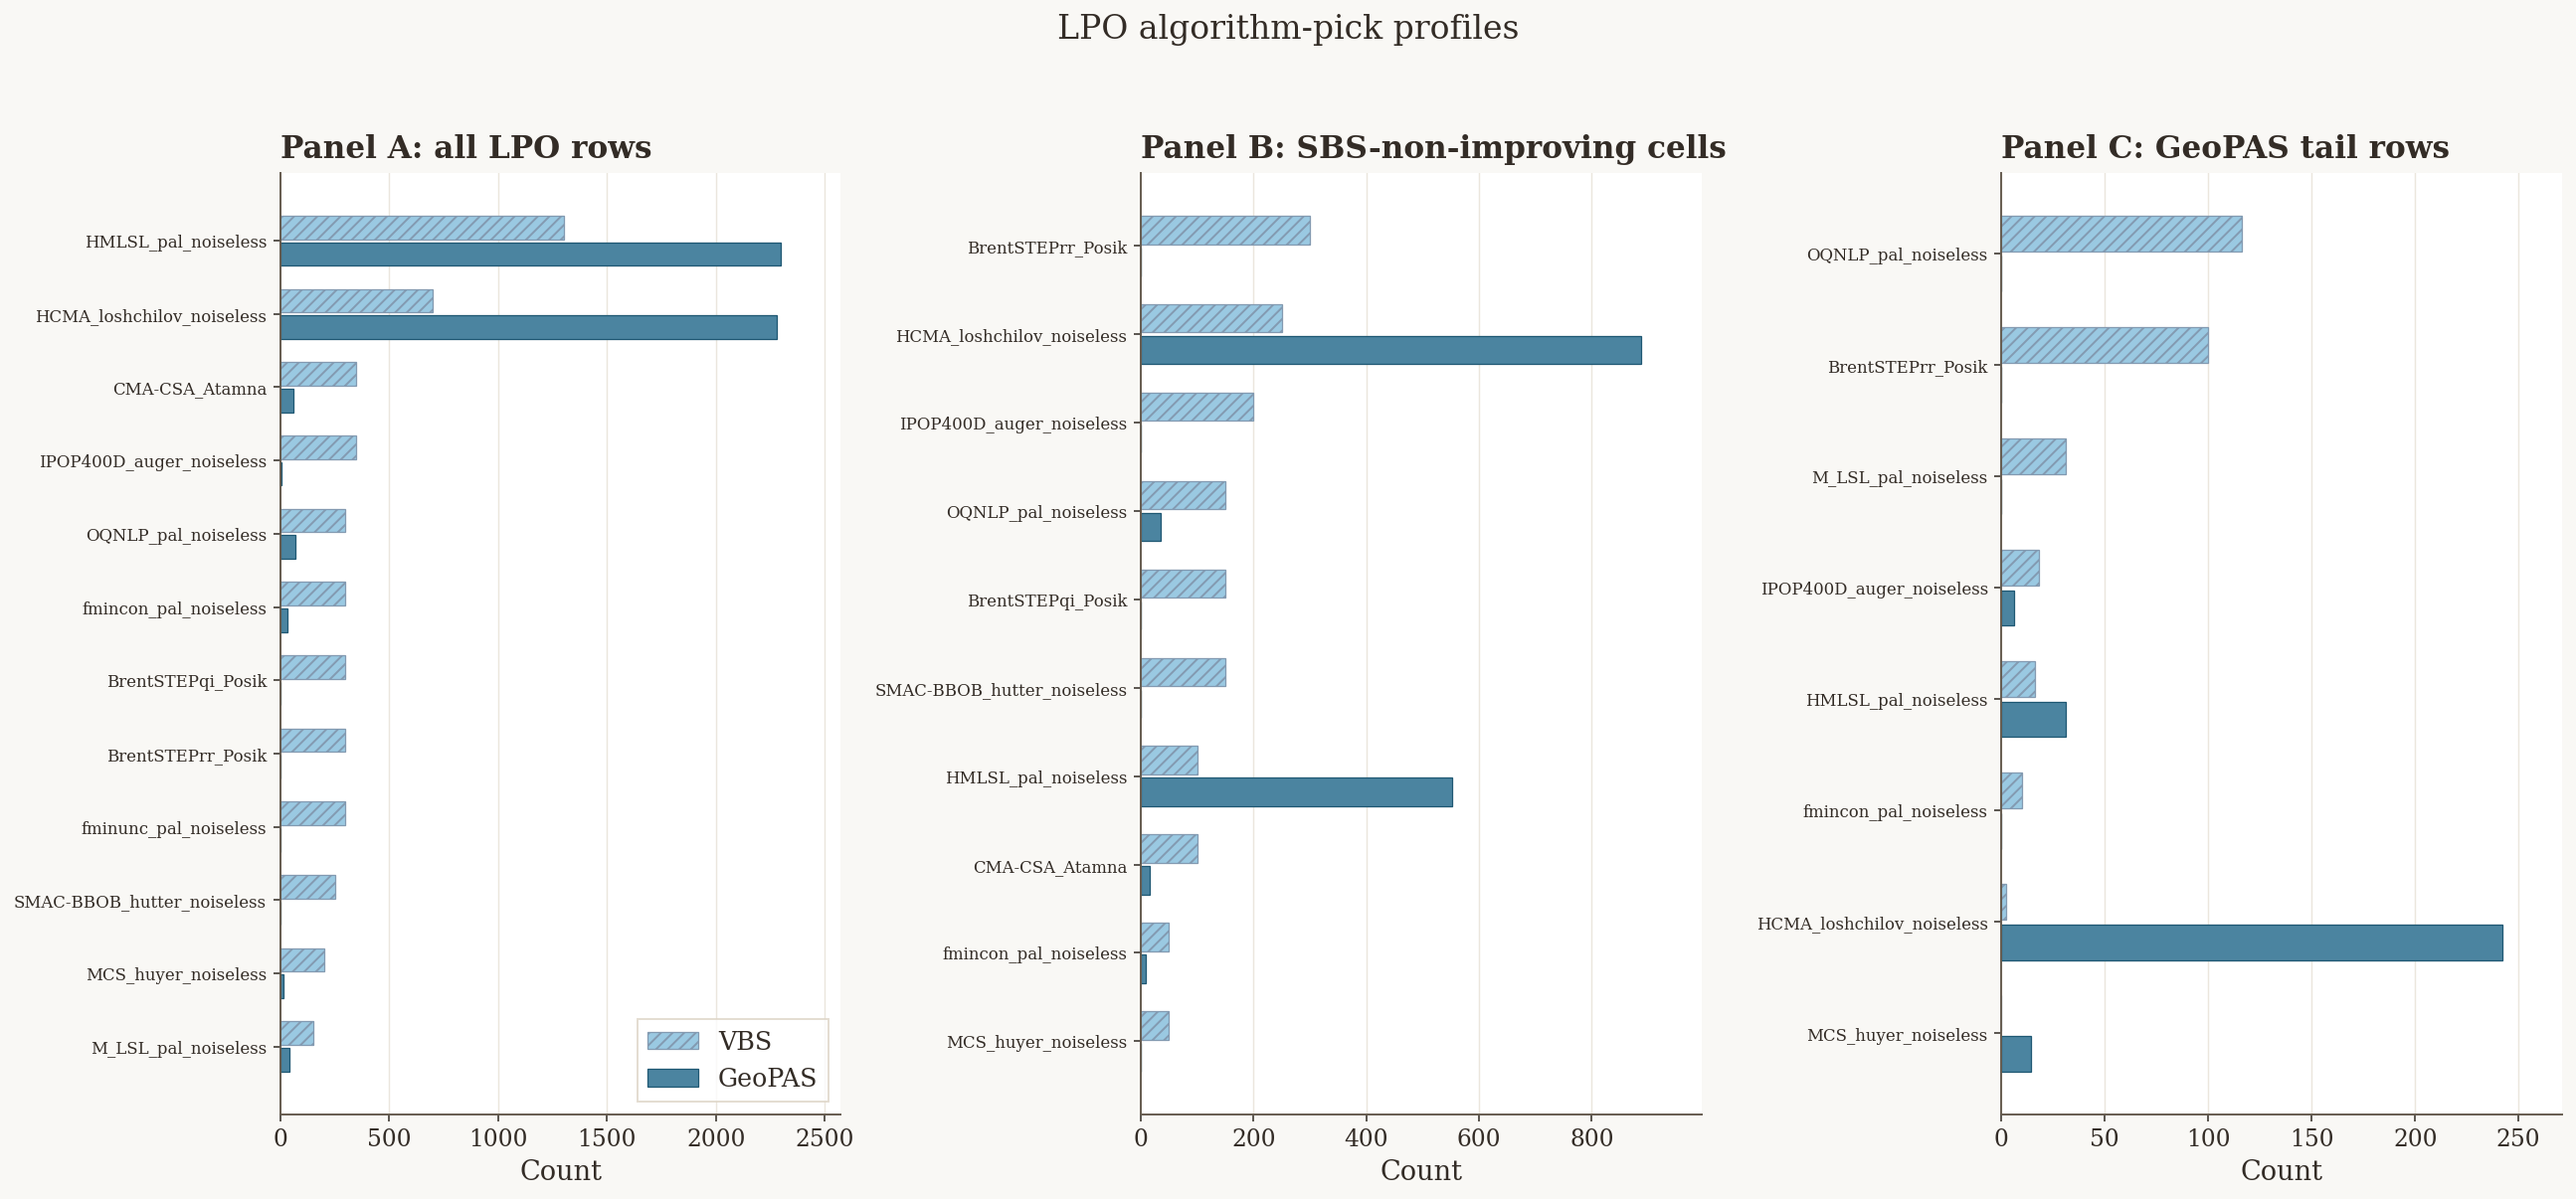

/data1/home/jw1017/AS_BBO_REBUILT/GeoPAS_v1/analysis_outputs/failure_analysis/scalelog_tail1_cap3.0_thr3.0_scale1.0_dual1_w10.0_tau0.5_pen10.51__seed17__res8__k32/fig_pickfreq_lpo_all_nonimproving_tail.svg


In [116]:
lpo_non_improving_df = subset_non_improving_rows(lpo_df, non_improving_cells)
lpo_tail_df = lpo_df.loc[lpo_df["as_tail_T"]].copy()

fig_pick, axes_pick = plt.subplots(1, 3, figsize=(18.6, 8.4), facecolor=FIGURE_FACE)
fig_pick.suptitle("LPO algorithm-pick profiles", fontsize=17, color=TEXT_COLOR, y=1.02)
plot_pick_frequency_panel(axes_pick[0], lpo_df, "Panel A: all LPO rows", show_legend=True)
plot_pick_frequency_panel(axes_pick[1], lpo_non_improving_df, "Panel B: SBS-non-improving cells", show_legend=False)
plot_pick_frequency_panel(axes_pick[2], lpo_tail_df, "Panel C: GeoPAS tail rows", show_legend=False)
fig_pick.tight_layout(rect=(0.0, 0.0, 1.0, 0.98))
fig_pick_path = config.output_dir / "fig_pickfreq_lpo_all_nonimproving_tail.svg"
fig_pick.savefig(fig_pick_path, bbox_inches="tight", facecolor=FIGURE_FACE)
plt.show()
print(fig_pick_path)

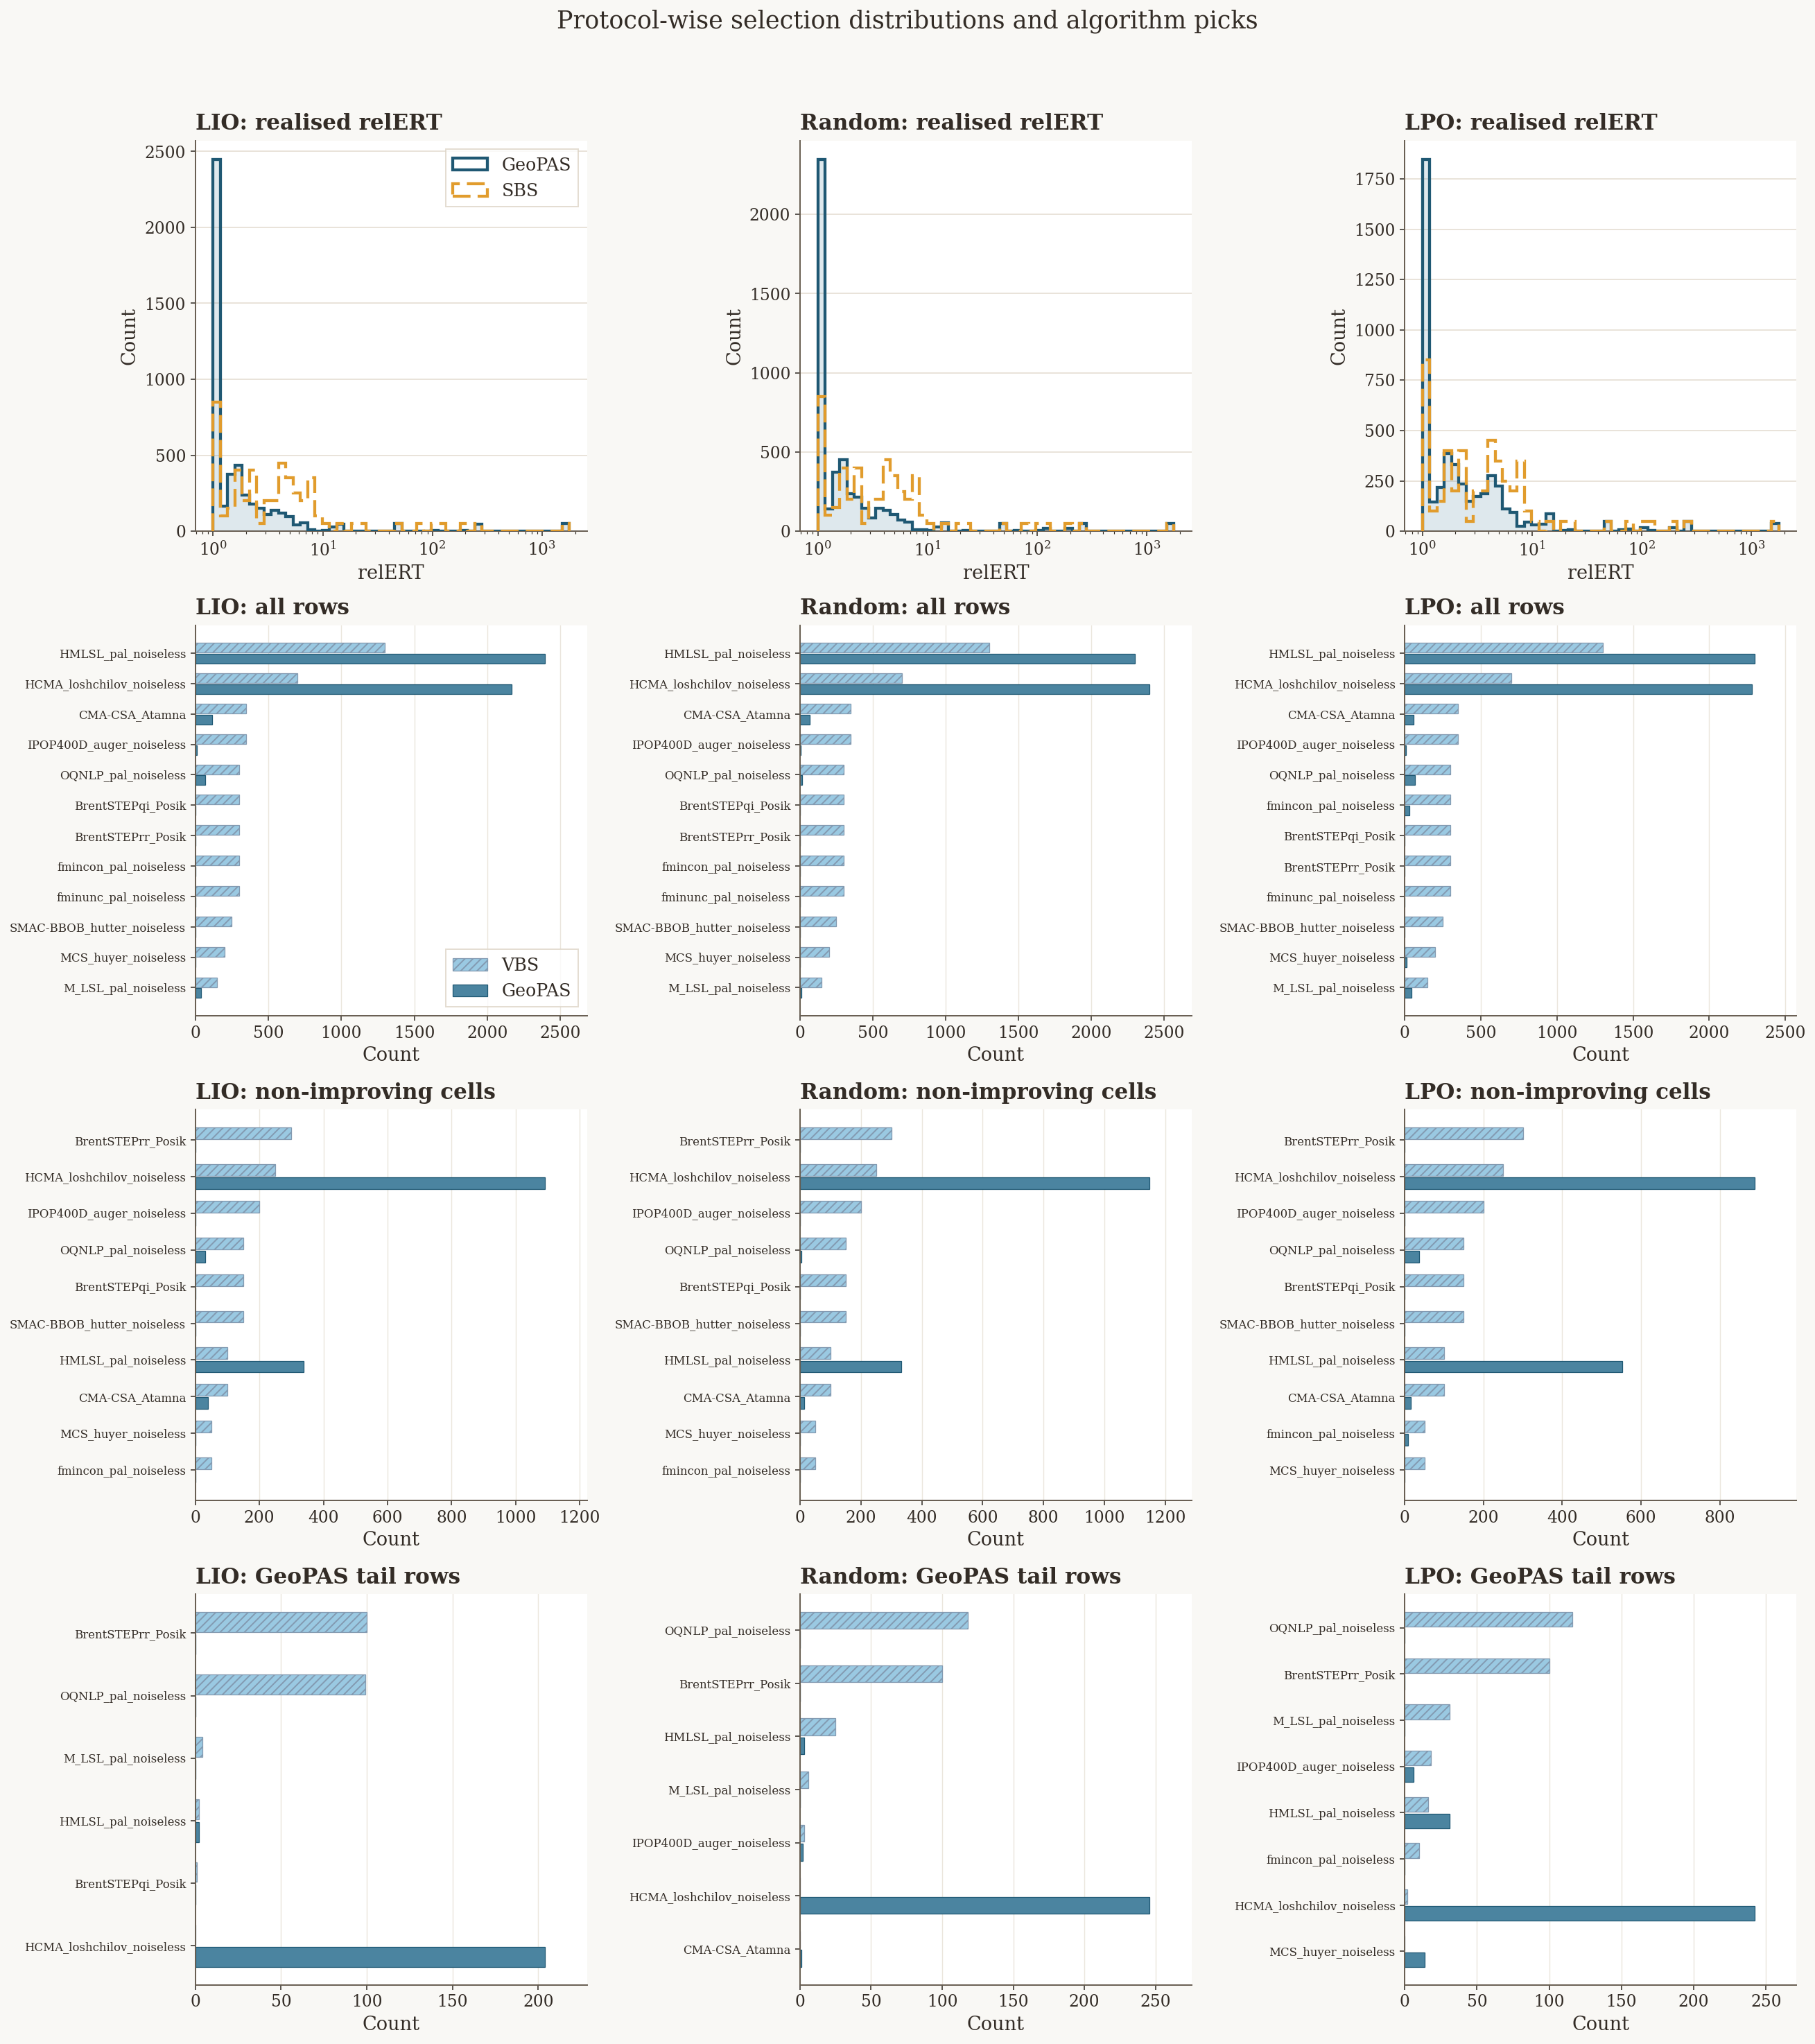

/data1/home/jw1017/AS_BBO_REBUILT/GeoPAS_v1/analysis_outputs/failure_analysis/scalelog_tail1_cap3.0_thr3.0_scale1.0_dual1_w10.0_tau0.5_pen10.51__seed17__res8__k32/fig_protocolwise_selection_distributions_and_pickfreqs.svg


In [117]:
shared_hist_bins = make_log_bins(
    *(protocol_df["as_score"].to_numpy(dtype=float) for protocol_df in analysis_by_protocol.values()),
    *(protocol_df["sbs_score"].to_numpy(dtype=float) for protocol_df in analysis_by_protocol.values()),
)

fig_grid, axes_grid = plt.subplots(4, 3, figsize=(18.8, 20.8), facecolor=FIGURE_FACE)
fig_grid.suptitle("Protocol-wise selection distributions and algorithm picks", fontsize=18, color=TEXT_COLOR, y=1.01)
for col_index, protocol in enumerate(config.protocols):
    protocol_df = analysis_by_protocol[protocol]
    non_improving_df = subset_non_improving_rows(protocol_df, non_improving_cells)
    tail_df = protocol_df.loc[protocol_df["as_tail_T"]].copy()
    hist_groups, hist_group_order, hist_group_colors, hist_legend_title = resolve_histogram_grouping(
        protocol_df,
        hist_color_by,
    )

    plot_histogram_comparison(
        axes_grid[0, col_index],
        protocol_df["as_score"].to_numpy(dtype=float),
        protocol_df["sbs_score"].to_numpy(dtype=float),
        bins=shared_hist_bins,
        title=f"{protocol}: realised relERT",
        show_legend=(col_index == 0),
        count_scale=hist_count_scale,
        row_groups=hist_groups,
        group_order=hist_group_order,
        group_colors=hist_group_colors,
        group_target=hist_group_target,
        legend_title=hist_legend_title,
    )
    plot_pick_frequency_panel(axes_grid[1, col_index], protocol_df, f"{protocol}: all rows", show_legend=(col_index == 0))
    plot_pick_frequency_panel(axes_grid[2, col_index], non_improving_df, f"{protocol}: non-improving cells", show_legend=False)
    plot_pick_frequency_panel(axes_grid[3, col_index], tail_df, f"{protocol}: GeoPAS tail rows", show_legend=False)

fig_grid.tight_layout(rect=(0.0, 0.0, 1.0, 0.985))
fig_grid_path = config.output_dir / "fig_protocolwise_selection_distributions_and_pickfreqs.svg"
fig_grid.savefig(fig_grid_path, bbox_inches="tight", facecolor=FIGURE_FACE)
plt.show()
print(fig_grid_path)

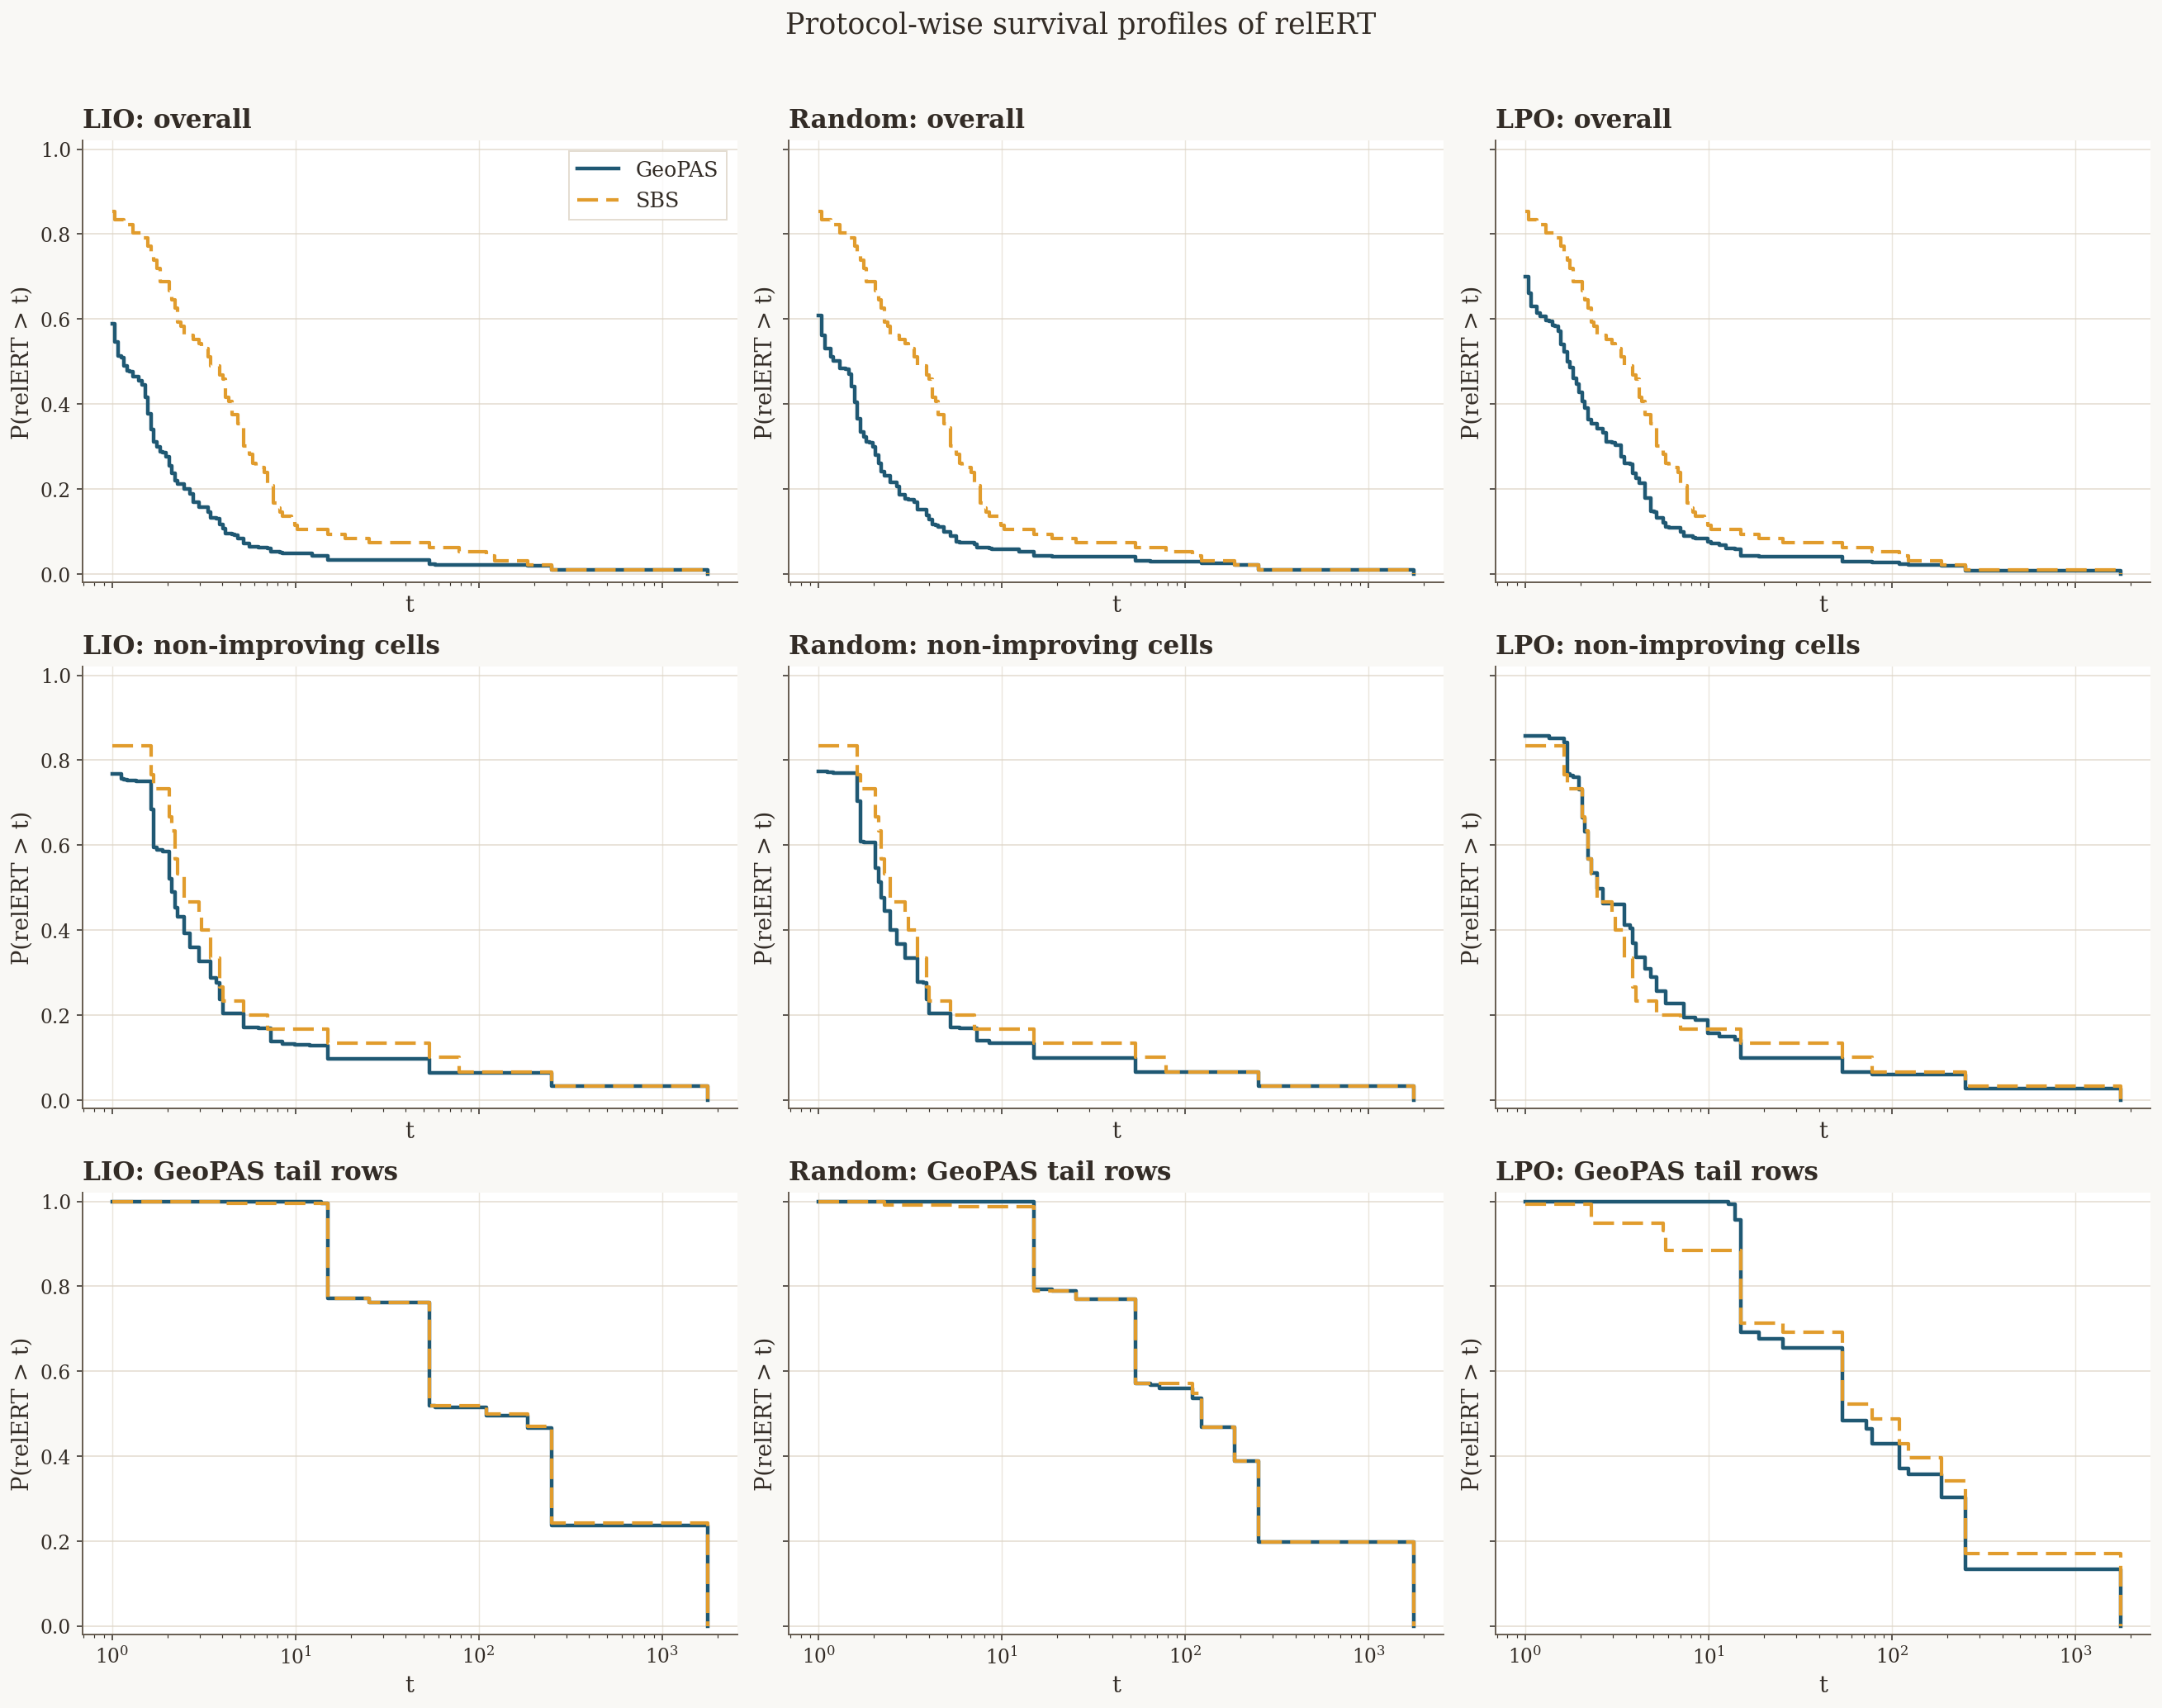

/data1/home/jw1017/AS_BBO_REBUILT/GeoPAS_v1/analysis_outputs/failure_analysis/scalelog_tail1_cap3.0_thr3.0_scale1.0_dual1_w10.0_tau0.5_pen10.51__seed17__res8__k32/fig_protocolwise_survival_curves.svg


In [118]:
survival_grid = build_survival_grid(analysis_by_protocol)

fig_survival, axes_survival = plt.subplots(3, 3, figsize=(18.8, 14.8), facecolor=FIGURE_FACE, sharex=True, sharey=True)
fig_survival.suptitle("Protocol-wise survival profiles of relERT", fontsize=18, color=TEXT_COLOR, y=0.995)
for col_index, protocol in enumerate(config.protocols):
    protocol_df = analysis_by_protocol[protocol]
    non_improving_df = subset_non_improving_rows(protocol_df, non_improving_cells)
    tail_df = protocol_df.loc[protocol_df["as_tail_T"]].copy()

    plot_survival_panel(axes_survival[0, col_index], protocol_df, survival_grid, f"{protocol}: overall", show_legend=(col_index == 0))
    plot_survival_panel(axes_survival[1, col_index], non_improving_df, survival_grid, f"{protocol}: non-improving cells", show_legend=False)
    plot_survival_panel(axes_survival[2, col_index], tail_df, survival_grid, f"{protocol}: GeoPAS tail rows", show_legend=False)

fig_survival.tight_layout(rect=(0.0, 0.0, 1.0, 0.975))
fig_survival_path = config.output_dir / "fig_protocolwise_survival_curves.svg"
fig_survival.savefig(fig_survival_path, bbox_inches="tight", facecolor=FIGURE_FACE)
plt.show()
print(fig_survival_path)

## Validation

Two validation conventions matter here:

1. The failure-analysis tail flags use the configured **broadcast** threshold `T`, defined from the 4800-row SBS broadcast.
2. The `res_*.csv` summary files use the original generator convention for SBS/VBS baselines, where the baseline tables are computed on the 96-row ground-truth label table rather than the broadcast rows.

The summary-table checks below follow the generator convention so they can be compared directly with `res_*.csv`. The requested tail-quadrant target table is also checked explicitly; with the current artifacts it does not match exactly, so the notebook reports the mismatch unless `config.strict_target_count_validation` is turned on.

In [119]:
summary_validation_frames = []
for protocol in config.protocols:
    for metric in ["Mean", "Median", "P90"]:
        for section in ["AS", "SBS"]:
            summary_validation_frames.append(
                compare_summary_tables(
                    observed_tables_by_protocol[protocol][metric][section],
                    result_tables_by_protocol[protocol][metric][section],
                    protocol=protocol,
                    metric=metric,
                    section=section,
                    tol=config.csv_compare_tol,
                )
            )

summary_validation_df = pd.concat(summary_validation_frames, ignore_index=True)
protocol_level_validation_df = summary_validation_df.loc[
    (summary_validation_df["Problem Group"] == "all") & (summary_validation_df["Dim"] == "all")
].copy()
cell_level_validation_df = summary_validation_df.loc[
    (summary_validation_df["Problem Group"] != "all") & (summary_validation_df["Dim"] != "all")
].copy()

assert protocol_level_validation_df["within_tol"].all(), "Protocol-level summary validation failed."
assert cell_level_validation_df["within_tol"].all(), "Cell-level summary validation failed."
assert non_improving_cells == EXPECTED_NON_IMPROVING_CELLS

save_dataframe(summary_validation_df, config.output_dir / "validation_summary_tables.csv")
save_dataframe(protocol_level_validation_df, config.output_dir / "validation_protocol_summary_tables.csv")
save_dataframe(cell_level_validation_df, config.output_dir / "validation_cell_summary_tables.csv")

print("Protocol-level summary validation: PASS")
print("Cell-level summary validation: PASS")
print(f"SBS-non-improving subset: PASS -> {sorted(non_improving_cells)}")
print(f"Strict target count validation enabled: {config.strict_target_count_validation}")

protocol_level_validation_df

Protocol-level summary validation: PASS
Cell-level summary validation: PASS
SBS-non-improving subset: PASS -> [('f1-f5', 3), ('f1-f5', 5), ('f1-f5', 10), ('f15-f19', 3), ('f15-f19', 5), ('f20-f24', 3)]
Strict target count validation enabled: False


,Protocol,Metric,Section,Problem Group,Dim,observed,expected,abs_diff,within_tol
29,LIO,Mean,AS,all,all,23.189,23.189,0.0,True
59,LIO,Mean,SBS,all,all,30.373,30.373,0.0,True
89,LIO,Median,AS,all,all,1.137,1.137,0.0,True
119,LIO,Median,SBS,all,all,3.438,3.438,0.0,True
149,LIO,P90,AS,all,all,4.101,4.101,0.0,True
179,LIO,P90,SBS,all,all,12.477,12.477,0.0,True
209,Random,Mean,AS,all,all,24.712,24.712,0.0,True
239,Random,Mean,SBS,all,all,30.373,30.373,0.0,True
269,Random,Median,AS,all,all,1.274,1.274,0.0,True
299,Random,Median,SBS,all,all,3.438,3.438,0.0,True


In [120]:
produced_artifacts = pd.DataFrame(
    {
        "artifact": sorted(path.name for path in config.output_dir.iterdir())
    }
)
produced_artifacts

,artifact
0,cell_summary_by_protocol.csv
1,fig_hist_relert_lpo_geopas_vs_sbs.svg
2,fig_pickfreq_lpo_all_nonimproving_tail.svg
3,fig_protocolwise_selection_distributions_and_p...
4,fig_protocolwise_survival_curves.svg
5,per_row_analysis__lio.csv.gz
6,per_row_analysis__lpo.csv.gz
7,per_row_analysis__random.csv.gz
8,protocol_level_summary.csv
9,sbs_non_improving_cells.csv
